In [1]:
SAMPLE_KB = [
    "产品：CloudSync Pro。功能：支持最多 5 台设备实时同步、1TB 云存储、离线模式、30 天版本历史记录。",
    "价格：基础版 9 美元/月（100GB、2 台设备），专业版 19 美元/月（1TB、5 台设备），企业版 49 美元/月（5TB、不限设备数量）。",
    "取消订阅：可随时在“账户 > 订阅 > 取消订阅”中操作。付款后 14 天内可申请退款。",
    "密码重置：进入登录页面，点击“忘记密码”，输入注册邮箱。重置链接有效期为 1 小时。",
    "同步问题：请检查网络连接，确认应用已更新到最新版本，然后尝试退出登录并重新登录。如果问题仍然存在，请联系客户支持。",
    "支持的平台：Windows 10 及以上、macOS 12 及以上、iOS 15 及以上、Android 10 及以上、Linux（测试版）。",
    "数据安全：静态和传输过程均采用 AES-256 加密，通过 SOC 2 Type II 认证，采用零知识架构。",
    "文件大小限制：基础版单个文件最大 2GB；专业版和企业版单个文件最大 10GB。文件总数量不限。",
]

ESCALATION_KEYWORDS = [
    "退款",
    "诉讼",
    "起诉",
    "愤怒",
    "暴怒",
    "欺诈",
    "诈骗",
    "损坏",
    "故障",
    "数据丢失",
    "注销账户",
    "取消账号",
    "扣费",
    "收费",
    "账单错误",
    "计费错误"
]

In [2]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages
from langchain_core.messages import BaseMessage

class SupportState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages] # 对话历史
    user_input: str # 用户输入
    retrieved_context: str #保存 RAG 检索出来的知识库内容
    response: str  # 保存最终生成给用户的回答
    escalate: bool # 表示是否需要人工升级

In [45]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv
import os

load_dotenv()

embeddings_model = os.getenv('EMBEDDING_MODEL', 'text-embedding-v4')
base_url = os.getenv('OPENAI_BASE_URL', '')

class Retriever:
    def __init__(self, kb_texts):
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=200,
            chunk_overlap=20
        )

        docs_split = splitter.create_documents(kb_texts)

        print(docs_split)

        embeddings = OpenAIEmbeddings(model=embeddings_model, base_url=base_url, check_embedding_ctx_length=False)

        self.vectorstore = FAISS.from_documents(
            docs_split,
            embeddings
        )

    def retrieve(self, query: str) -> SupportState:
        docs = self.vectorstore.similarity_search(query, k=3)
        context = "\n".join(d.page_content for d in docs)
        return {"retrieved_context": context}

retriever = Retriever(SAMPLE_KB)

def retrieve_context(state: SupportState) -> SupportState:
    return retriever.retrieve(query=state['user_input'])

[Document(metadata={}, page_content='产品：CloudSync Pro。功能：支持最多 5 台设备实时同步、1TB 云存储、离线模式、30 天版本历史记录。'), Document(metadata={}, page_content='价格：基础版 9 美元/月（100GB、2 台设备），专业版 19 美元/月（1TB、5 台设备），企业版 49 美元/月（5TB、不限设备数量）。'), Document(metadata={}, page_content='取消订阅：可随时在“账户 > 订阅 > 取消订阅”中操作。付款后 14 天内可申请退款。'), Document(metadata={}, page_content='密码重置：进入登录页面，点击“忘记密码”，输入注册邮箱。重置链接有效期为 1 小时。'), Document(metadata={}, page_content='同步问题：请检查网络连接，确认应用已更新到最新版本，然后尝试退出登录并重新登录。如果问题仍然存在，请联系客户支持。'), Document(metadata={}, page_content='支持的平台：Windows 10 及以上、macOS 12 及以上、iOS 15 及以上、Android 10 及以上、Linux（测试版）。'), Document(metadata={}, page_content='数据安全：静态和传输过程均采用 AES-256 加密，通过 SOC 2 Type II 认证，采用零知识架构。'), Document(metadata={}, page_content='文件大小限制：基础版单个文件最大 2GB；专业版和企业版单个文件最大 10GB。文件总数量不限。')]


In [46]:
def check_escalation(state: SupportState) -> SupportState:
    text = state['user_input'].lower()
    needs_escalation = any(kw in text for kw in ESCALATION_KEYWORDS)
    return {"escalate": needs_escalation}

In [47]:
'退款' in '商品有瑕疵，我要退款'

True

In [48]:
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser

SYSTEM_PROMPT = """
你是 CloudSync Pro 的智能客服助手。

请使用以下知识库上下文来准确回答用户的问题：

{retrieved_context}

回答时请保持友好、简洁，并以解决问题为导向。
如果你不确定答案，请诚实说明。
"""

model = os.getenv("MODEL_NAME", '')

llm = ChatOpenAI(model=model, temperature=0.2, extra_body={'enable_thinking': False})

def generate_response(state: SupportState) -> SupportState:
    conversation = state["messages"][:-1]
    if state.get('escalate'):
        response_text = '我理解您的担忧，我会确保这个问题得到应有的重视，我正在为您转接高级支持专员，他们可以直接处理这个问题，您将在 2 小时内收到回复。您的服务工单编号为#'+ str(hash(state["user_input"]) % 100000) + "。"
    else:
        messages = [
            SystemMessage(content=SYSTEM_PROMPT.format(retrieved_context=state["retrieved_context"])),
            *conversation,
            HumanMessage(content=state["user_input"])
        ]
        response_text = (llm | StrOutputParser()).invoke(input=messages)
        print('='*200, '\n')
        print(state['messages'])
        print('='*200, '\n')
        return { 'response': response_text, 'messages': [AIMessage(content=response_text)] }

In [49]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

def build_graph():
    graph = StateGraph(SupportState)
    graph.add_node("retrieve", retrieve_context)
    graph.add_node("check_escalation", check_escalation)
    graph.add_node("generate", generate_response)
    graph.add_edge(START, 'retrieve')
    graph.add_edge("retrieve", "check_escalation")
    graph.add_edge("check_escalation", "generate")
    graph.add_edge("generate", END)
    agent = graph.compile()
    display(Image(agent.get_graph().draw_mermaid_png()))
    return agent

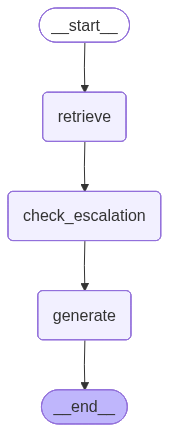

In [50]:
agent = build_graph()

input_state: SupportState = { 'user_input': '', 'messages': [], 'escalate': False, 'retrieved_context': '', 'response': '' }

In [51]:
from typing import cast


user_input = '怎么取消订阅'

input_state['user_input'] = user_input
input_state['messages'].append(HumanMessage(content=user_input))

input_state = cast(SupportState, agent.invoke(input_state))

escalation_indicator = " [ESCALATED]" if input_state.get("escalate") else ""
print(f"\nAgent{escalation_indicator}: {input_state['response']}\n")


[HumanMessage(content='怎么取消订阅', additional_kwargs={}, response_metadata={}, id='863f7058-5d51-4658-bdac-5fc03e2ed310')]


Agent: 您好！取消订阅非常简单，您可以按照以下步骤操作：

1. 进入 **“账户”** 页面。
2. 点击 **“订阅”**。
3. 选择 **“取消订阅”** 即可完成操作。

另外提醒您，如果在付款后 **14 天内**，您还可以申请退款。

如果操作中遇到任何问题，欢迎随时联系我！



In [52]:
input_state['user_input'] = '怎样重置密码'
input_state = cast(SupportState, agent.invoke(input_state))
# print(input_state)


[HumanMessage(content='怎么取消订阅', additional_kwargs={}, response_metadata={}, id='863f7058-5d51-4658-bdac-5fc03e2ed310'), AIMessage(content='您好！取消订阅非常简单，您可以按照以下步骤操作：\n\n1. 进入 **“账户”** 页面。\n2. 点击 **“订阅”**。\n3. 选择 **“取消订阅”** 即可完成操作。\n\n另外提醒您，如果在付款后 **14 天内**，您还可以申请退款。\n\n如果操作中遇到任何问题，欢迎随时联系我！', additional_kwargs={}, response_metadata={}, id='41734870-e090-4367-9353-898fe6e236f1', tool_calls=[], invalid_tool_calls=[])]



In [53]:
input_state['user_input'] = '产品价格'
input_state = cast(SupportState, agent.invoke(input_state))

for msg in input_state['messages']:
    print("*"*200, '\n')
    print(msg, '\n')
    print("*"*200, '\n')


[HumanMessage(content='怎么取消订阅', additional_kwargs={}, response_metadata={}, id='863f7058-5d51-4658-bdac-5fc03e2ed310'), AIMessage(content='您好！取消订阅非常简单，您可以按照以下步骤操作：\n\n1. 进入 **“账户”** 页面。\n2. 点击 **“订阅”**。\n3. 选择 **“取消订阅”** 即可完成操作。\n\n另外提醒您，如果在付款后 **14 天内**，您还可以申请退款。\n\n如果操作中遇到任何问题，欢迎随时联系我！', additional_kwargs={}, response_metadata={}, id='41734870-e090-4367-9353-898fe6e236f1', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='您好！很高兴为您解答这两个问题：\n\n**1. 如何取消订阅**\n您可以随时在 **“账户 > 订阅 > 取消订阅”** 中操作。如果您是在付款后 14 天内，还可以申请退款。\n\n**2. 如何重置密码**\n请进入登录页面，点击 **“忘记密码”**，然后输入您的注册邮箱。系统会发送重置链接给您，请注意该链接的有效期为 **1 小时**。\n\n如果还有其他疑问，欢迎随时联系我！', additional_kwargs={}, response_metadata={}, id='ff770a5e-9c2b-4756-b3f1-61ed424d84e8', tool_calls=[], invalid_tool_calls=[])]

******************************************************************************************************************************************************************************************************** 

content='怎么取消订阅' additional_kwargs